# ODE Model of an Inflammatory Feedback Network

**Bistability, bifurcation analysis, and global sensitivity analysis of a coupled cell-cytokine system.**

This notebook implements a coupled ordinary differential equation (ODE) model of an
inflammatory feedback network comprising an activated immune-cell population and three
cytokines - TNF-alpha, IL-6, and IL-10. The pro-inflammatory cytokines (TNF-alpha, IL-6)
drive recruitment and activation of immune cells, which in turn produce more cytokines
(positive feedback). IL-10 provides anti-inflammatory negative feedback by suppressing
both recruitment and pro-inflammatory cytokine production.

The interplay of these feedback loops produces **bistability**: for a range of parameters
the system has two coexisting stable steady states - a *resolved* state (inflammation
clears) and a *chronic* state (inflammation persists) - separated by an unstable saddle
equilibrium. Which state is reached depends on the strength of the initial immune
challenge.

**Analyses performed**
1. Trajectory simulation showing resolved vs. chronic outcomes from the same parameter set.
2. Equilibrium location by root-finding and stability classification via Jacobian eigenvalues.
3. A bifurcation diagram traced by numerical continuation, revealing a hysteresis loop bounded by two saddle-node bifurcations.
4. Basins of attraction in the space of initial conditions.
5. Variance-based global sensitivity analysis (Sobol indices) identifying the parameters that most strongly drive the chronic outcome.
6. A two-parameter regime map delineating monostable and bistable regions.

The model structure follows established ODE models of acute inflammation
(Reynolds et al. 2006; Day et al. 2006; Herald 2010). Parameter values are illustrative
and chosen to place the system in the biologically relevant bistable regime; the model
reproduces the *qualitative* bistability described in those works rather than fitting any
specific dataset.


## 1 - Environment

In [1]:
# Colab: SALib is not pre-installed
!pip install SALib --quiet

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze
from itertools import product

np.random.seed(42)
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

# Consistent colour scheme across all figures
C_RESOLVED, C_CHRONIC, C_UNSTABLE = "#2c7fb8", "#d95f0e", "#7a7a7a"

## 2 - Model definition

The state vector is $y = [M,\ T,\ I_6,\ I_{10}]$:

| Symbol | Meaning |
|--------|---------|
| $M$    | activated immune-cell population (e.g. macrophages) |
| $T$    | TNF-alpha concentration (pro-inflammatory) |
| $I_6$  | IL-6 concentration (pro-inflammatory) |
| $I_{10}$ | IL-10 concentration (anti-inflammatory) |

Pro-inflammatory cytokines recruit cells through **activating Hill functions**; IL-10
suppresses recruitment and pro-inflammatory production through **inhibitory Hill
functions**. The shared Hill coefficient $n$ sets the cooperativity of these switches and
is the key structural parameter enabling bistability.

$$\dot M = \Big(s_M + k_{MT}\,h^+(T,K_{MT}) + k_{MI6}\,h^+(I_6,K_{MI6})\Big)\,h^-(I_{10},K_{M10})\,\Big(1-\tfrac{M}{M_{\max}}\Big) - d_M M$$
$$\dot T = p_T\,M\,h^-(I_{10},K_{T10}) - d_T T$$
$$\dot I_6 = p_{I6}\,M\,h^-(I_{10},K_{I610}) - d_{I6} I_6$$
$$\dot I_{10} = p_{I10}\,M\,h^+(I_6,K_{106}) - d_{I10} I_{10}$$

where $h^+(x,k)=x^n/(k^n+x^n)$ and $h^-(x,k)=k^n/(k^n+x^n)$.


In [2]:
def hill_act(x, k, n):
    """Activating Hill function: rises 0 -> 1 as x increases."""
    xn = np.power(np.maximum(x, 0.0), n)
    return xn / (np.power(k, n) + xn)

def hill_inh(x, k, n):
    """Inhibitory Hill function: falls 1 -> 0 as x increases."""
    xn = np.power(np.maximum(x, 0.0), n)
    return np.power(k, n) / (np.power(k, n) + xn)

DEFAULT_PARAMS = {
    # --- activated immune-cell population M ---
    "s_M":    0.01,   # baseline (cytokine-independent) recruitment
    "k_MT":   1.20,   # recruitment driven by TNF-alpha
    "k_MI6":  0.50,   # recruitment driven by IL-6
    "K_MT":   1.00,   # half-saturation, TNF-alpha recruitment
    "K_MI6":  1.50,   # half-saturation, IL-6 recruitment
    "d_M":    0.15,   # cell clearance / apoptosis rate
    "M_max":  8.00,   # carrying capacity of activated cells
    # --- TNF-alpha ---
    "p_T":    1.20,   # TNF-alpha production per activated cell
    "K_T10":  0.60,   # IL-10 half-saturation suppressing TNF-alpha
    "d_T":    1.10,   # TNF-alpha decay rate
    # --- IL-6 ---
    "p_I6":   0.90,   # IL-6 production per activated cell
    "K_I610": 0.70,   # IL-10 half-saturation suppressing IL-6
    "d_I6":   0.80,   # IL-6 decay rate
    # --- IL-10 (anti-inflammatory) ---
    "p_I10":  0.80,   # IL-10 production per activated cell
    "K_106":  1.20,   # IL-6 half-saturation driving IL-10 production
    "d_I10":  0.90,   # IL-10 decay rate
    # --- IL-10 negative feedback onto recruitment ---
    "K_M10":  0.80,   # IL-10 half-saturation suppressing recruitment
    # --- shared Hill coefficient (structural) ---
    "n_hill": 3.0,    # cooperativity; drives switch-like behaviour
}

# Parameters varied in the sensitivity analysis (n_hill held fixed as structural)
PARAM_ORDER = [k for k in DEFAULT_PARAMS if k != "n_hill"]

def inflammation_rhs(y, p):
    """Right-hand side of the ODE system. y = [M, T, I6, I10]."""
    M, T, I6, I10 = [max(v, 0.0) for v in y]
    n = p["n_hill"]
    g10_M = hill_inh(I10, p["K_M10"],  n)   # IL-10 gate on recruitment
    g10_T = hill_inh(I10, p["K_T10"],  n)   # IL-10 gate on TNF-alpha
    g10_6 = hill_inh(I10, p["K_I610"], n)   # IL-10 gate on IL-6

    recruit = (p["s_M"]
               + p["k_MT"]  * hill_act(T,  p["K_MT"],  n)
               + p["k_MI6"] * hill_act(I6, p["K_MI6"], n)) * g10_M

    dM   = recruit * (1.0 - M / p["M_max"]) - p["d_M"] * M
    dT   = p["p_T"]   * M * g10_T                      - p["d_T"]   * T
    dI6  = p["p_I6"]  * M * g10_6                       - p["d_I6"]  * I6
    dI10 = p["p_I10"] * M * hill_act(I6, p["K_106"], n) - p["d_I10"] * I10
    return np.array([dM, dT, dI6, dI10])

def inflammation_ode(t, y, p):
    return inflammation_rhs(y, p)

STATE_LABELS = ["Activated cells  M", "TNF-alpha", "IL-6", "IL-10"]

## 3 - Integration, equilibria, and Jacobian-based stability

Equilibria are located by root-finding (`fsolve`) from a spread of initial guesses, and
each is classified by the eigenvalues of the numerically-evaluated Jacobian: an
equilibrium is **stable** if every eigenvalue has negative real part. Complex eigenvalues
indicate a **focus** (damped oscillatory approach) rather than a node.


In [3]:
def simulate(p, y0, t_end=200.0, n_points=2000):
    """Integrate the ODE system and return (t, y) on a dense grid."""
    t_eval = np.linspace(0, t_end, n_points)
    sol = solve_ivp(inflammation_ode, (0, t_end), y0, t_eval=t_eval,
                    args=(p,), method="LSODA", rtol=1e-8, atol=1e-10)
    return sol.t, sol.y

def steady_state(p, y0, t_end=1200.0):
    """Integrate to convergence; return the final state."""
    sol = solve_ivp(inflammation_ode, (0, t_end), y0, args=(p,),
                    method="LSODA", rtol=1e-9, atol=1e-11)
    return sol.y[:, -1]

def jacobian(y, p, eps=1e-6):
    """Numerical Jacobian via forward finite differences."""
    J = np.zeros((4, 4))
    f0 = inflammation_rhs(y, p)
    for j in range(4):
        yp = np.array(y, float); yp[j] += eps
        J[:, j] = (inflammation_rhs(yp, p) - f0) / eps
    return J

def classify(eq, p):
    """Return ('stable'|'unstable', eigenvalues) from the Jacobian spectrum."""
    ev = np.linalg.eigvals(jacobian(eq, p))
    return ("stable" if np.all(ev.real < 0) else "unstable"), ev

def find_equilibria(p, extra_guesses=None, tol=1e-3):
    """Find all distinct equilibria by root-finding from many initial guesses."""
    guesses = [[0.05, 0.05, 0.05, 0.00], [1.80, 0.80, 1.10, 0.70],
               [0.50, 0.30, 0.30, 0.10], [1.00, 0.50, 0.50, 0.30]]
    guesses += [[m, t, t * 0.8, t * 0.4]
                for m in (0.2, 0.6, 1.2, 2.0) for t in (0.2, 0.5, 0.9)]
    if extra_guesses is not None:
        guesses += [list(g) for g in extra_guesses]

    roots = []
    for g in guesses:
        r, _, ok, _ = fsolve(inflammation_rhs, g, args=(p,), full_output=True)
        if ok == 1 and np.all(r > -1e-6):
            r = np.maximum(r, 0.0)
            if not any(np.linalg.norm(r - e) < tol for e in roots):
                roots.append(r)
    return roots

# Two contrasting immune challenges (initial conditions)
low_challenge  = [0.1, 0.2, 0.1, 0.05]   # weak insult
high_challenge = [4.0, 5.0, 4.0, 0.05]   # strong insult

equilibria = find_equilibria(DEFAULT_PARAMS,
    extra_guesses=[steady_state(DEFAULT_PARAMS, low_challenge),
                   steady_state(DEFAULT_PARAMS, high_challenge)])

for eq in sorted(equilibria, key=lambda z: z[1]):
    kind, ev = classify(eq, DEFAULT_PARAMS)
    osc = "focus (complex lambda)" if np.any(np.abs(ev.imag) > 1e-6) else "node (real lambda)"
    print(f"equilibrium  M={eq[0]:.3f}  T={eq[1]:.3f}  I6={eq[2]:.3f}  "
          f"I10={eq[3]:.3f}   [{kind}, {osc}]   max Re(lambda)={ev.real.max():+.4f}")

equilibrium  M=0.070  T=0.076  I6=0.079  I10=0.000   [stable, node (real lambda)]   max Re(lambda)=-0.1221
equilibrium  M=0.259  T=0.283  I6=0.292  I10=0.003   [unstable, node (real lambda)]   max Re(lambda)=+0.1378
equilibrium  M=1.819  T=0.815  I6=1.075  I10=0.676   [stable, focus (complex lambda)]   max Re(lambda)=-0.5278


## 4 - Trajectories: resolved vs. chronic outcome

With **identical parameters**, the system is integrated from a weak and a strong initial
challenge. The weak challenge resolves; the strong challenge locks into the chronic state.
The damped overshoot visible in the chronic curves reflects the complex Jacobian
eigenvalues - the chronic equilibrium is a stable focus.


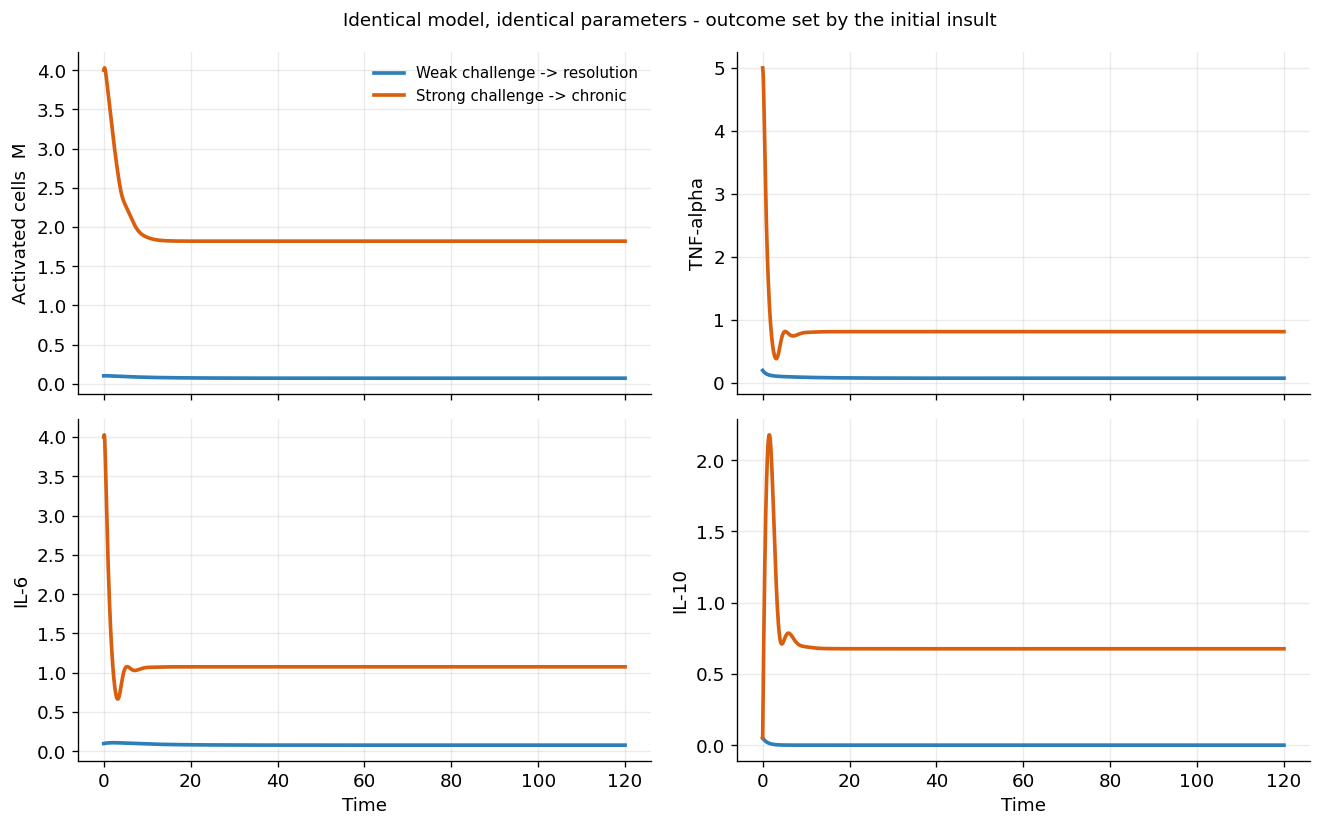

Resolved-state equilibrium : [0.0701 0.0765 0.0789 0.    ]
Chronic-state equilibrium  : [1.8185 0.8154 1.0754 0.6765]


In [4]:
t_lo, y_lo = simulate(DEFAULT_PARAMS, low_challenge,  t_end=120)
t_hi, y_hi = simulate(DEFAULT_PARAMS, high_challenge, t_end=120)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(t_lo, y_lo[i], color=C_RESOLVED, lw=2.2,
            label="Weak challenge -> resolution")
    ax.plot(t_hi, y_hi[i], color=C_CHRONIC, lw=2.2,
            label="Strong challenge -> chronic")
    ax.set_ylabel(STATE_LABELS[i])
    if i >= 2:
        ax.set_xlabel("Time")
    if i == 0:
        ax.legend(frameon=False, fontsize=9)
fig.suptitle("Identical model, identical parameters - outcome set by the initial insult",
             fontsize=11)
fig.tight_layout()
plt.show()

print("Resolved-state equilibrium :", np.round(y_lo[:, -1], 4))
print("Chronic-state equilibrium  :", np.round(y_hi[:, -1], 4))

## 5 - Bifurcation diagram: hysteresis via numerical continuation

The TNF-alpha production rate $p_T$ is swept across a range. At each value, **all**
equilibria are located and classified. Plotting equilibrium TNF-alpha against $p_T$ traces
three branches: a lower stable (resolved) branch, an upper stable (chronic) branch, and an
intermediate unstable branch forming the separatrix. The stable branches connect to the
unstable one at two **saddle-node (fold) bifurcations**, which bound the bistable region
and produce a hysteresis loop.


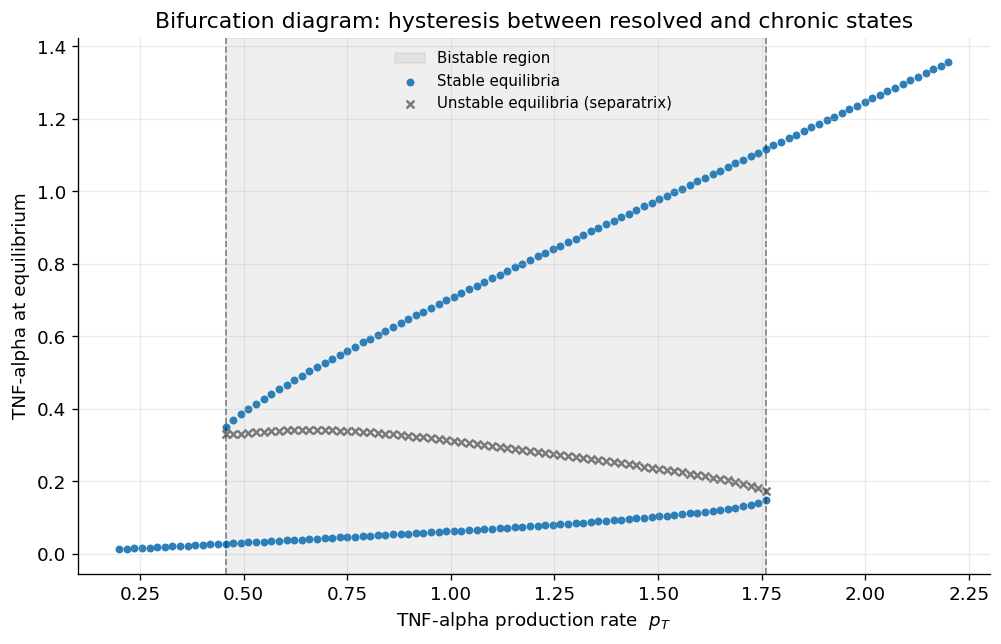

Bistable window:  p_T in [0.457, 1.760]
Outside this window the system is monostable (resolved for low p_T, chronic for high p_T).


In [5]:
pT_values = np.linspace(0.20, 2.20, 110)
stable_pts, unstable_pts = [], []

for pT in pT_values:
    p = dict(DEFAULT_PARAMS, p_T=pT)
    seeds = [steady_state(p, low_challenge), steady_state(p, high_challenge)]
    for eq in find_equilibria(p, extra_guesses=seeds):
        kind, _ = classify(eq, p)
        (stable_pts if kind == "stable" else unstable_pts).append((pT, eq[1]))

stable_pts   = np.array(stable_pts)
unstable_pts = np.array(unstable_pts)

# Bistable window = p_T range over which an unstable equilibrium exists
pT_lo = pT_hi = None
if len(unstable_pts):
    pT_lo, pT_hi = unstable_pts[:, 0].min(), unstable_pts[:, 0].max()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
if pT_lo is not None:
    ax.axvspan(pT_lo, pT_hi, color="grey", alpha=0.12, label="Bistable region")
    for pf in (pT_lo, pT_hi):
        ax.axvline(pf, ls="--", lw=1, color="k", alpha=0.45)
ax.scatter(stable_pts[:, 0], stable_pts[:, 1], s=14, color=C_RESOLVED,
           label="Stable equilibria")
ax.scatter(unstable_pts[:, 0], unstable_pts[:, 1], s=22, color=C_UNSTABLE,
           marker="x", label="Unstable equilibria (separatrix)")
ax.set_xlabel("TNF-alpha production rate  $p_T$")
ax.set_ylabel("TNF-alpha at equilibrium")
ax.set_title("Bifurcation diagram: hysteresis between resolved and chronic states")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

if pT_lo is not None:
    print(f"Bistable window:  p_T in [{pT_lo:.3f}, {pT_hi:.3f}]")
    print("Outside this window the system is monostable "
          "(resolved for low p_T, chronic for high p_T).")

## 6 - Basins of attraction

The model is 4-dimensional, so a true 2-D phase portrait is not available. Instead, the
plane of **initial conditions** in $(T_0, I_{10,0})$ is sampled on a dense grid (with $M$
and $I_6$ fixed at small "fresh insult" values); each seed is integrated to its steady
state and coloured by outcome. The resulting boundary is the genuine basin separatrix.
Representative 4-D trajectories are projected onto the same plane - because this is a
projection of a higher-dimensional flow, projected trajectories may appear to cross, which
is expected and not a numerical error.


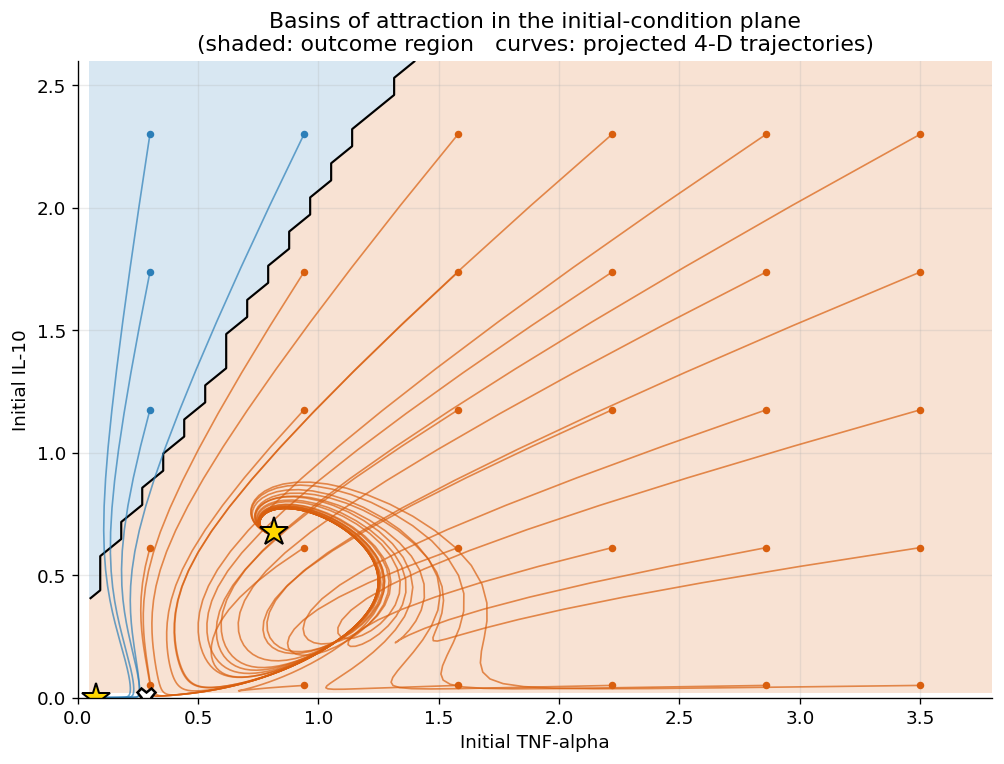

In [6]:
def outcome(eq, threshold=0.4):
    """Classify a steady state as chronic or resolved by its TNF-alpha level."""
    return "chronic" if eq[1] > threshold else "resolved"

# Basin map over the plane of initial conditions
T_seed   = np.linspace(0.05, 3.8, 44)
I10_seed = np.linspace(0.02, 2.6, 38)
basin = np.zeros((len(I10_seed), len(T_seed)))
for i, i10 in enumerate(I10_seed):
    for j, t0 in enumerate(T_seed):
        ss = steady_state(DEFAULT_PARAMS, [0.3, t0, 0.3, i10], t_end=400)
        basin[i, j] = 1.0 if outcome(ss) == "chronic" else 0.0

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.contourf(T_seed, I10_seed, basin, levels=[-0.5, 0.5, 1.5],
            colors=[C_RESOLVED, C_CHRONIC], alpha=0.18)
ax.contour(T_seed, I10_seed, basin, levels=[0.5], colors="k", linewidths=1.3)

# Representative 4-D trajectories projected onto the (TNF, IL-10) plane
for t0, i100 in product(np.linspace(0.3, 3.5, 6), np.linspace(0.05, 2.3, 5)):
    _, y = simulate(DEFAULT_PARAMS, [0.3, t0, 0.3, i100], t_end=300)
    col = C_CHRONIC if outcome(y[:, -1]) == "chronic" else C_RESOLVED
    ax.plot(y[1], y[3], color=col, lw=1.0, alpha=0.7)
    ax.plot(t0, i100, "o", color=col, ms=3.5)

# Mark equilibria (projected): stars = stable, X = unstable
for eq in find_equilibria(DEFAULT_PARAMS):
    kind, _ = classify(eq, DEFAULT_PARAMS)
    if kind == "stable":
        ax.plot(eq[1], eq[3], "*", color="k", ms=18, mfc="gold", mew=1.2)
    else:
        ax.plot(eq[1], eq[3], "X", color="k", ms=11, mfc="white", mew=1.5)

ax.set_xlabel("Initial TNF-alpha"); ax.set_ylabel("Initial IL-10")
ax.set_xlim(0, 3.8); ax.set_ylim(0, 2.6)
ax.set_title("Basins of attraction in the initial-condition plane\n"
             "(shaded: outcome region   curves: projected 4-D trajectories)")
fig.tight_layout()
plt.show()

## 7 - Global sensitivity analysis: Sobol indices

A variance-based global sensitivity analysis quantifies how much each parameter
contributes to the chronic-inflammation outcome. The model output is the steady-state
TNF-alpha reached from the strong-challenge initial condition - a proxy for chronic
severity. All 17 kinetic parameters are varied +/-40% around their nominal values using
Saltelli sampling, and first-order ($S_1$) and total-order ($S_T$) Sobol indices are
computed.

- $S_1$ - fraction of output variance from a parameter acting **alone**.
- $S_T$ - fraction including **all interactions** involving that parameter.
- A large gap $S_T - S_1$ indicates the parameter acts mainly through interactions.

Parameters with the highest $S_T$ are the strongest leverage points - the candidate
**therapeutic targets** in a disease-modelling interpretation.


In [7]:
problem = {
    "num_vars": len(PARAM_ORDER),
    "names": PARAM_ORDER,
    "bounds": [[0.6 * DEFAULT_PARAMS[k], 1.4 * DEFAULT_PARAMS[k]]
               for k in PARAM_ORDER],
}

# Total model evaluations = N * (2D + 2). N=128 -> ~4,600 integrations (~75 s on CPU).
# Raise N to 256 for tighter bootstrap confidence intervals (~5 min).
N = 128
param_values = sobol_sample.sample(problem, N, calc_second_order=True)
print(f"Saltelli samples: {param_values.shape[0]} parameter sets")

def _ss_fast(p, y0, t_end=400.0):
    """Faster steady-state solve for the GSA sweep.

    Uses looser tolerances and a shorter horizon than steady_state(); the
    system always settles well before t=400, and Sobol indices are
    insensitive to the resulting <1e-9 differences. This keeps the
    ~4,600-integration sweep to about a minute on a Colab CPU.
    """
    sol = solve_ivp(inflammation_ode, (0, t_end), y0, args=(p,),
                    method="LSODA", rtol=1e-6, atol=1e-8)
    return sol.y[:, -1]

def chronic_severity(row):
    """Steady-state TNF-alpha from the strong challenge = chronic-severity metric."""
    p = {**{k: v for k, v in zip(PARAM_ORDER, row)},
         "n_hill": DEFAULT_PARAMS["n_hill"]}
    return _ss_fast(p, high_challenge)[1]

Y = np.array([chronic_severity(row) for row in param_values])

Si = sobol_analyze.analyze(problem, Y, calc_second_order=True,
                           print_to_console=False, seed=42)
print("Sobol analysis complete.")

Saltelli samples: 4608 parameter sets


Sobol analysis complete.


## 8 - Sensitivity ranking and interaction structure

The left panel ranks parameters by total-order index with bootstrap 95% confidence
intervals. The right panel shows the matrix of second-order indices $S_2$, exposing which
**pairs** of parameters interact in driving the chronic outcome.


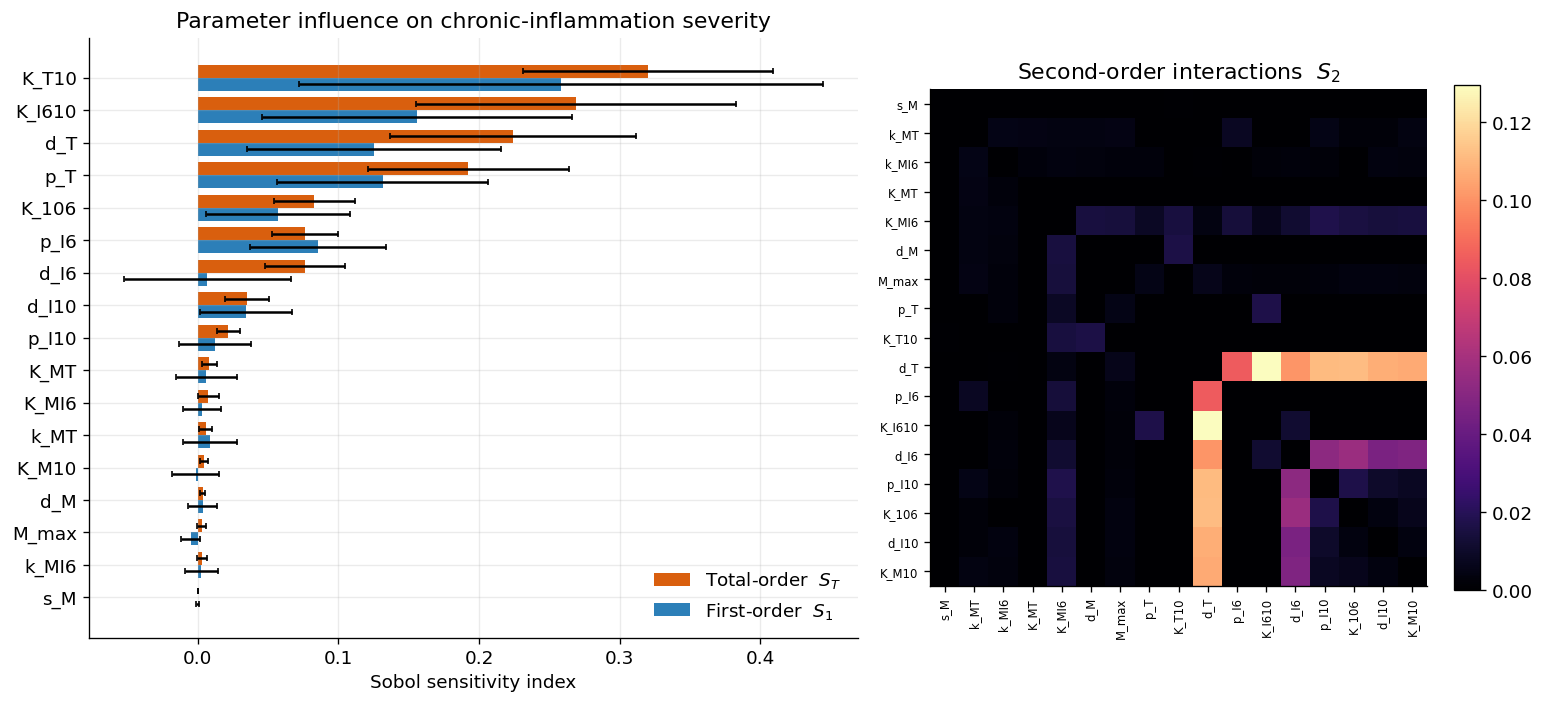

Ranked drivers of chronic inflammation (candidate therapeutic targets):
param           S1        ST   interaction
K_T10       +0.258    +0.320        +0.062
K_I610      +0.156    +0.269        +0.113
d_T         +0.125    +0.224        +0.099
p_T         +0.132    +0.193        +0.061
K_106       +0.057    +0.083        +0.026
p_I6        +0.086    +0.076        -0.009
d_I6        +0.007    +0.076        +0.070
d_I10       +0.034    +0.035        +0.001
p_I10       +0.013    +0.022        +0.009
K_MT        +0.006    +0.008        +0.002
K_MI6       +0.003    +0.008        +0.004
k_MT        +0.009    +0.006        -0.003
K_M10       -0.001    +0.005        +0.006
d_M         +0.004    +0.004        +0.000
M_max       -0.005    +0.003        +0.008
k_MI6       +0.003    +0.003        +0.000
s_M         +0.000    +0.000        -0.000


In [8]:
order = np.argsort(Si["ST"])[::-1]
names = [PARAM_ORDER[i] for i in order]
S1, ST   = np.array(Si["S1"])[order],      np.array(Si["ST"])[order]
S1c, STc = np.array(Si["S1_conf"])[order], np.array(Si["ST_conf"])[order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6),
                               gridspec_kw={"width_ratios": [1.4, 1]})

yp = np.arange(len(names))
ax1.barh(yp - 0.2, ST, height=0.4, xerr=STc, capsize=2,
         color=C_CHRONIC, label="Total-order  $S_T$")
ax1.barh(yp + 0.2, S1, height=0.4, xerr=S1c, capsize=2,
         color=C_RESOLVED, label="First-order  $S_1$")
ax1.set_yticks(yp); ax1.set_yticklabels(names)
ax1.invert_yaxis()
ax1.set_xlabel("Sobol sensitivity index")
ax1.set_title("Parameter influence on chronic-inflammation severity")
ax1.legend(frameon=False)

S2 = np.array(Si["S2"])
S2 = np.nan_to_num(S2)
S2 = np.clip(S2 + S2.T, 0, None)
im = ax2.imshow(S2, cmap="magma")
ax2.set_xticks(range(len(PARAM_ORDER)))
ax2.set_yticks(range(len(PARAM_ORDER)))
ax2.set_xticklabels(PARAM_ORDER, rotation=90, fontsize=7)
ax2.set_yticklabels(PARAM_ORDER, fontsize=7)
ax2.set_title("Second-order interactions  $S_2$")
ax2.grid(False)
fig.colorbar(im, ax=ax2, fraction=0.046)
fig.tight_layout()
plt.show()

print("Ranked drivers of chronic inflammation (candidate therapeutic targets):")
print(f"{'param':8s} {'S1':>9s} {'ST':>9s} {'interaction':>13s}")
for i in order:
    interaction = Si["ST"][i] - Si["S1"][i]
    print(f"{PARAM_ORDER[i]:8s} {Si['S1'][i]:+9.3f} {Si['ST'][i]:+9.3f} "
          f"{interaction:+13.3f}")

## 9 - Two-parameter regime map

The two most influential parameters from the Sobol ranking are swept simultaneously. At
each point the number of stable equilibria is counted, partitioning the plane into a
**monostable resolved** region (one stable state) and a **bistable** region (two stable
states, chronic inflammation possible). The boundary between them is a curve of
saddle-node bifurcations.


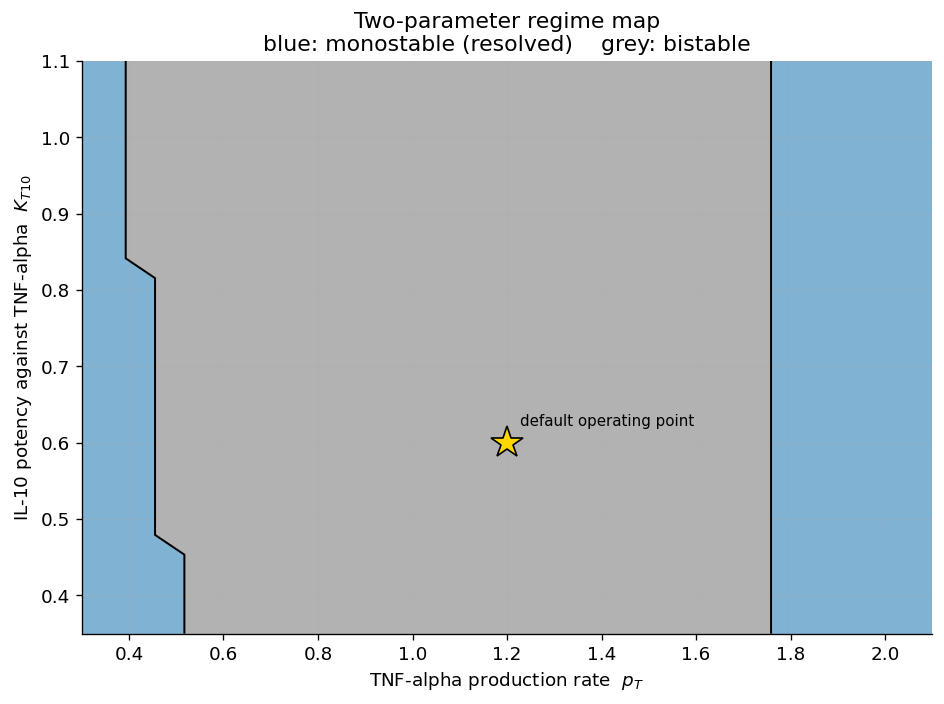

In [9]:
def count_stable(p):
    eqs = find_equilibria(p,
        extra_guesses=[steady_state(p, low_challenge),
                       steady_state(p, high_challenge)])
    return sum(classify(eq, p)[0] == "stable" for eq in eqs)

pT_axis   = np.linspace(0.30, 2.10, 30)
KT10_axis = np.linspace(0.35, 1.10, 30)
regime = np.zeros((len(KT10_axis), len(pT_axis)))
for i, kt in enumerate(KT10_axis):
    for j, pt in enumerate(pT_axis):
        regime[i, j] = count_stable(dict(DEFAULT_PARAMS, p_T=pt, K_T10=kt))

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(pT_axis, KT10_axis, regime, levels=[0.5, 1.5, 2.5],
            colors=[C_RESOLVED, "grey"], alpha=0.6)
ax.contour(pT_axis, KT10_axis, regime, levels=[1.5], colors="k", linewidths=1.2)
ax.plot(DEFAULT_PARAMS["p_T"], DEFAULT_PARAMS["K_T10"], "*",
        ms=20, mfc="gold", mec="k", zorder=5)
ax.annotate("default operating point",
            xy=(DEFAULT_PARAMS["p_T"], DEFAULT_PARAMS["K_T10"]),
            xytext=(8, 10), textcoords="offset points", fontsize=9)
ax.set_xlabel("TNF-alpha production rate  $p_T$")
ax.set_ylabel("IL-10 potency against TNF-alpha  $K_{T10}$")
ax.set_title("Two-parameter regime map\n"
             "blue: monostable (resolved)    grey: bistable")
fig.tight_layout()
plt.show()

## 10 - Summary

- **Bistability.** At the default parameters the system has three coexisting equilibria - a stable resolved state, a stable chronic state, and an unstable saddle separating their basins - confirmed by Jacobian eigenvalue analysis.
- **Hysteresis.** Sweeping the TNF-alpha production rate $p_T$ reveals a bistable window bounded by two saddle-node bifurcations; outside it the system is monostable.
- **Sensitivity.** Global Sobol analysis identifies the IL-10-mediated suppression parameters together with TNF-alpha production and decay as the dominant drivers of the chronic outcome - the model's candidate therapeutic targets.
- **Regime map.** The two-parameter sweep delineates exactly where chronic inflammation becomes dynamically accessible.

**Scope and caveats.** Parameter values are illustrative and chosen to place the system in
the bistable regime; the model reproduces the *qualitative* bistability of published
inflammation models rather than fitting a specific dataset. Bistability depends on
sufficient feedback cooperativity - reducing the Hill coefficient `n_hill` narrows or
removes the bistable window. The framework is modular: the cell-cytokine structure,
Hill-type feedback, continuation, and Sobol analysis can be re-parameterised for other
systems in which cytokine dynamics drive disease progression, including organ-on-chip
models.

**References.**
Reynolds A. et al. (2006) *J. Theor. Biol.* 242:220-236.
Day J. et al. (2006) *J. Theor. Biol.* 242:237-256.
Herald M.C. (2010) *J. Theor. Biol.* 264:935-945.
Saltelli A. et al. (2010) *Comput. Phys. Commun.* 181:259-270.
